# K-means Clustering 

# Outline
- [ 1 - Implementing K-means](#1)
  - [ 1.1 Finding closest centroids](#1.1)
    - [ Step 1]
  - [ 1.2 Computing centroid means](#1.2)
    - [ Step 2]
- [ 2 - K-means on a sample dataset ](#2)
- [ 3 - Random initialization](#3)
- [ 4 - Image compression with K-means](#4)
  - [ 4.1 Load the IMAGE](#4.1)
  - [ 4.2 K-Means on image pixels](#4.2)
  - [ 4.3 Compress the image](#4.3)


In [16]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

<a name="1"></a>
## 1 - Implementing K-means
The K-means algorithm is an unsupervised learning algorithm that aims to group  
similar data points.  

* The training set in unsupervised learning problems will look like this:
 $\{x^{(1)}, ..., x^{(m)}\}$, and the goal is
to group the data into a few cohesive “clusters”.  

K-means starts by initializing centroids randomly. each centroid is a vector that represent the center of each cluster/group  

K-means algorithm after initializing centroids will repeatedly go through two steps:  
1. Points labeling: assign each point to its closest centroid K
2. recalculate centroids

<a name="1.1"></a>
### 1.1 Finding closest centroids

In the “cluster assignment” phase of the K-means algorithm, the
algorithm assigns every training example $x^{(i)}$ to its closest
centroid, given the current positions of centroids. 

### Step 1
### `find_closest_centroids` Function

The function assigns each data point in $X$ to its nearest centroid in `centroids`.

**Inputs:**

* `X`: Data matrix.
* `centroids`: Locations of all centroids.

**Output:**

* `idx`: A 1D array where `idx[i]` is the index $(0 \text{ to } K-1)$ of the closest centroid to example $x^{(i)}$.

**Logic:**
For each example $x^{(i)}$, find the index $j$ that minimizes the squared L2-norm:


$$c^{(i)} := \arg \min_j ||x^{(i)} - \mu_j||^2$$

* $c^{(i)}$: Index of the closest centroid for $x^{(i)}$.
* $\mu_j$: Position of the $j$-th centroid.

In [17]:
def find_closest_centroids(X, centroids):
    """
    Computes the centroid memberships for every example
    
    Args:
        X (ndarray): (m, n) Input values      
        centroids (ndarray): (K, n) centroids
    
    Returns:
        idx (array_like): (m,) closest centroids
    
    """
    K = centroids.shape[0]
    idx = np.zeros(X.shape[0], dtype=int)

    for i in range(len(idx)):
        min_array = np.zeros(centroids.shape,dtype = float)
        min_numbers = np.zeros(K,dtype = float)
        for j in range(K):
            min_array[j] = (X[i] - centroids[j])**2
            min_numbers[j] = np.sum(min_array[j])
        x_to_k = np.argmin(min_numbers)
        idx[i] = x_to_k

    return idx

To complete the second phase of the K-means algorithm, I need to implement the `compute_centroids` function. My goal is to recompute the value of each centroid by calculating the mean of all data points currently assigned to it.

### My Implementation Logic

For every centroid $\mu_k$, I will update its position using the following formula:

$$\mu_k = \frac{1}{|C_k|} \sum_{i \in C_k} x^{(i)}$$

In this expression:

* $C_k$ represents the set of all examples I have assigned to centroid $k$.
* $|C_k|$ is the total count of examples within that set.

In [18]:
def compute_centroids(X, idx, K):
    """
    Returns the new centroids by computing the means of the 
    data points assigned to each centroid.
    
    Args:
        X (ndarray):   (m, n) Data points
        idx (ndarray): (m,) Array containing index of closest centroid for each 
                       example in X. Concretely, idx[i] contains the index of 
                       the centroid closest to example i
        K (int):       number of centroids
    
    Returns:
        centroids (ndarray): (K, n) New centroids computed
    """

    m, n = X.shape
    centroids = np.zeros((K, n))
    
    for i in range(K):
        c_mask = (idx == i)
        c_k = X[c_mask]
        if len(c_k) > 0:
            centroids[i] = (1/len(c_k))*(np.sum(c_k,axis = 0))
    
    return centroids

In [19]:
def plot_progress_kMeans(X, centroids, previous_centroids, idx, K, iteration):
    # Plot the data points colored by their assigned cluster index
    plt.scatter(X[:, 0], X[:, 1], c=idx, cmap='viridis', marker='o', alpha=0.5, edgecolors='k')
    
    # Plot the current centroids as red 'X' markers
    plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', c='red', s=100, linewidths=3)
    
    # Plot the movement from the previous centroids
    for j in range(K):
        plt.plot([centroids[j, 0], previous_centroids[j, 0]], 
                 [centroids[j, 1], previous_centroids[j, 1]], 
                 c='black', linestyle='--', linewidth=1)
    
    plt.title(f'K-Means Iteration {iteration}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

In [20]:
# You do not need to implement anything for this part

def run_kMeans(X, initial_centroids, max_iters=10, plot_progress=False):
    """
    Runs the K-Means algorithm on data matrix X, where each row of X
    is a single example
    """
    m, n = X.shape
    K = initial_centroids.shape[0]
    centroids = initial_centroids
    previous_centroids = centroids    
    idx = np.zeros(m)
    plt.figure(figsize=(8, 6))

    for i in range(max_iters):
        print("K-Means iteration %d/%d" % (i, max_iters-1))
        
        idx = find_closest_centroids(X, centroids)
        
        if plot_progress:
            plot_progress_kMeans(X, centroids, previous_centroids, idx, K, i)
            previous_centroids = centroids
            
        centroids = compute_centroids(X, idx, K)
    plt.show() 
    return centroids, idx

## Random Initializations of K centroids

In [21]:
def kMeans_init_centroids(X, K):
    """
    This function initializes K centroids that are to be 
    used in K-Means on the dataset X
    
    Args:
        X (ndarray): Data points 
        K (int):     number of centroids/clusters
    
    Returns:
        centroids (ndarray): Initialized centroids
    """
    randidx = np.random.permutation(X.shape[0])
    centroids = X[randidx[:K]]
    
    return centroids

You can run K-Means again but this time with random initial centroids. Run the cell below several times and observe how different clusters are created based on the initial points chosen.

In [22]:
def load_random():
    """
    This function loads a random dataset to utilize for experiments

    Args:
        No arguments
    
    Returns:
        X (ndarray): the random sample dataset
    
    """
    c1 = np.random.normal(0, 0.5, (33, 3))
    c2 = np.random.normal(5, 0.8, (33, 3))
    c3 = np.random.normal([10, 0, 5], 0.6, (34, 3))
    X = np.vstack((c1, c2, c3))
    np.random.shuffle(X)
    return X

K-Means iteration 0/9
K-Means iteration 1/9
K-Means iteration 2/9
K-Means iteration 3/9
K-Means iteration 4/9
K-Means iteration 5/9
K-Means iteration 6/9
K-Means iteration 7/9
K-Means iteration 8/9
K-Means iteration 9/9


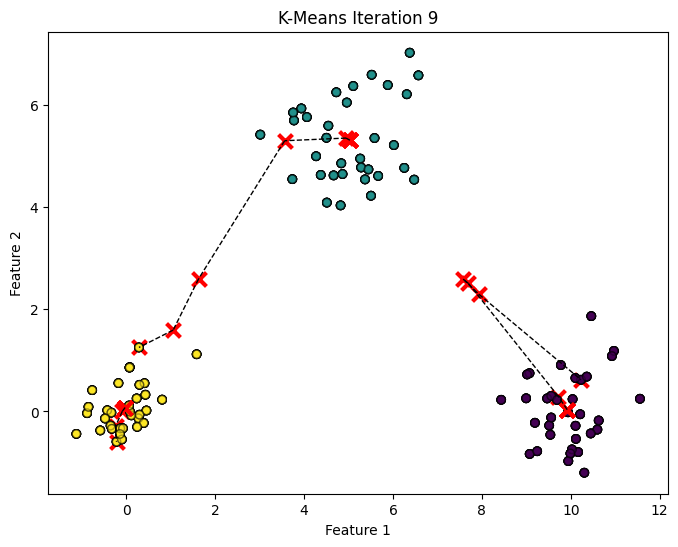

In [23]:
X = load_random()

# Set number of centroids and max number of iterations
K = 3
max_iters = 10

# Set initial centroids by picking random examples from the dataset
initial_centroids = kMeans_init_centroids(X, K)

# Run K-Means
centroids, idx = run_kMeans(X, initial_centroids, max_iters, plot_progress=True)

## Image compression with K-means
Normally, each pixel in a photo uses a 24-bit RGB system. That means for every single dot, I have to store three different numbers (Red, Green, Blue) that each go from 0 to 255. When you have thousands of pixels, each with a unique shade, that could consume a lot of memory because of the many different possible combination between the RGB channels.  

**My Plan for Compression**:

we will allow for only 16 colors. what does that mean? 
``` 
Color 1 → (250, 10, 20)
Color 2 → (20, 240, 30)
Color 3 → (10, 20, 240)
Color 16 → (200, 200, 50)
```

So, instead of storing RGB for every pixel like this pixel = (220,100,70)  
we will do this  
`pixel → color number` 
```
pixel1 → color 3
pixel2 → color 7
pixel3 → color 1
```  
**This Reduce the Size to 4 bits rather than 8 bits**

In [24]:
# Load an image of a bird
original_img = plt.imread('bird.webp')

**Visualize image**

visualizing the image that was just loaded using the code below.

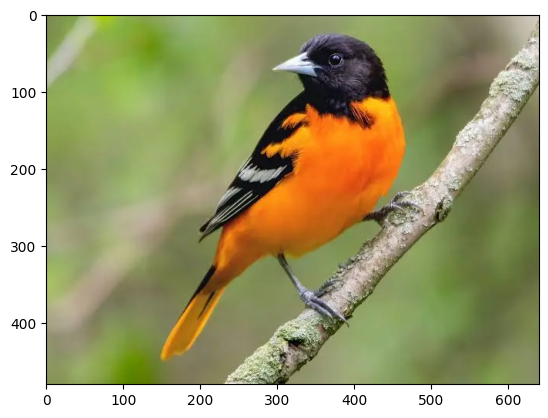

In [25]:
plt.imshow(original_img)

**Check the dimension of the variable**

As always, printing out the shape of the variable to get more familiar with the data.

In [26]:
print("Shape of original_img is:", original_img.shape)

Shape of original_img is: (480, 640, 3)


As you can see, this creates a three-dimensional matrix `original_img` where 
* the first two indices identify a pixel position, and
* the third index represents red, green, or blue. 

For example, `original_img[50, 33, 2]` gives the blue intensity of the pixel at row 50 and column 33.

#### Processing data

To call the `run_kMeans`, you need to first transform the matrix `original_img` into a two-dimensional matrix.

* The code below reshapes the matrix `original_img` to create an $m \times 3$ matrix of pixel colors

In [ ]:
# Standardization
original_img = original_img / 255

# Reshape the image into an m x 3 matrix where m = number of pixels
# Each row will contain the Red, Green and Blue pixel values.

X_img = np.reshape(original_img, (original_img.shape[0] * original_img.shape[1], 3))

<a name="4.2"></a>
### 4.2 K-Means on image pixels

Now, run the cell below to run K-Means on the pre-processed image.

In [19]:
K = 16
max_iters = 10

initial_centroids = kMeans_init_centroids(X_img, K)

centroids, idx = run_kMeans(X_img, initial_centroids, max_iters)

K-Means iteration 0/9
K-Means iteration 1/9
K-Means iteration 2/9
K-Means iteration 3/9
K-Means iteration 4/9
K-Means iteration 5/9
K-Means iteration 6/9
K-Means iteration 7/9
K-Means iteration 8/9
K-Means iteration 9/9


<Figure size 800x600 with 0 Axes>

In [20]:
print("Shape of idx:", idx.shape)
print("Closest centroid for the first five elements:", idx[:5])

Shape of idx: (307200,)
Closest centroid for the first five elements: [8 8 8 8 8]


Visualizing learned colors

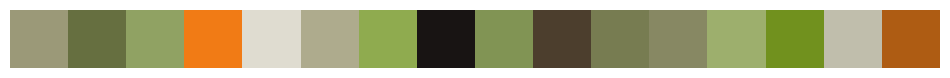

In [21]:
import matplotlib.pyplot as plt
import numpy as np
display_palette = np.array(centroids).reshape(1, 16, 3)

plt.figure(figsize=(12, 2))
plt.imshow(display_palette)
plt.axis('off')
plt.show()

<a name="4.3"></a>
### 4.3 Compress the image


After finding the top $K=16$ colors to represent the image, you can now
assign each pixel position to its closest centroid using the
`find_closest_centroids` function. 
* This allows you to represent the original image using the centroid assignments of each pixel. 
* Notice that you have significantly reduced the number of bits that are required to describe the image. 
    * The original image required 24 bits (i.e. 8 bits x 3 channels in RGB encoding) for each one of the $128\times128$ pixel locations, resulting in total size of $480 \times 640 \times 24 = 7,372,800$ bits. 
    * The new representation requires some overhead storage in form of a dictionary of 16 colors, each of which require 24 bits, but the image itself then only requires 4 bits per pixel location. 
    * The final number of bits used is therefore $16 \times 24 + 480 \times 640 \times 4 = 1,229,184$ bits, which corresponds to compressing the original image by about a factor of 6.

In [22]:
idx = find_closest_centroids(X_img, centroids)

X_recovered = centroids[idx, :] 

X_recovered = np.reshape(X_recovered, original_img.shape) 

# Comparison: Original Vs Compressed

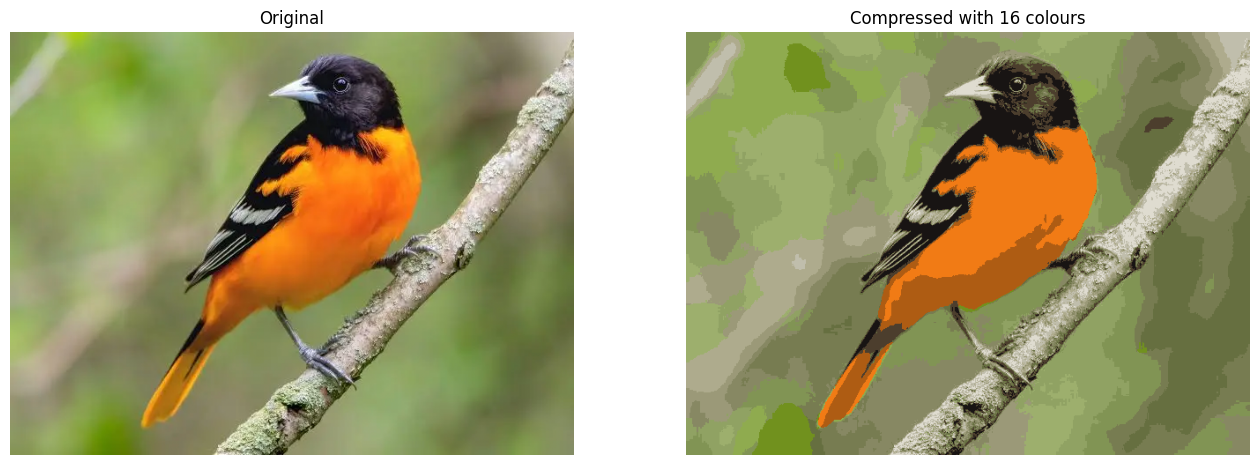

In [23]:
# Display original image
fig, ax = plt.subplots(1,2, figsize=(16,16))
plt.axis('off')

ax[0].imshow(original_img)
ax[0].set_title('Original')
ax[0].set_axis_off()


# Display compressed image
ax[1].imshow(X_recovered)
ax[1].set_title('Compressed with %d colours'%K)
ax[1].set_axis_off()